# Bitcoin — log warp regression

Tutorial notebook: **daily Bitcoin log-price** with a presized macro sine driver, warp path, and MLP readout.

### What is warp regression?

Many time series look like a **driver** (sine wave, input signal, trend) that has been **shifted in time** before being read out. Warp regression learns:

1. **A warp path** `p(i)` on sample **index** `i` — how far to slide the driver at each observation.
2. **A readout** that maps the warped driver to the target `y`.

Conceptually: `ŷ(i) = readout( soft_warp(driver, p)[i] )`.

### Dual likelihood (error + terror)

Training balances two terms controlled by **`fit_lambda = λ`**:

| Term | Meaning |
|------|---------|
| **Error NLL** (`obj_err`) | Gaussian fit of residuals — how well `ŷ` matches `y` |
| **Terror / path LL** (`obj_time`) | Random-walk prior on warp **offsets** `p(i)−i` — penalises jagged, implausible warps |

`loss = λ·obj_err − (1−λ)·obj_time`. Smaller `λ` trusts the path prior more; larger `λ` chases fit quality.

### Forecast uncertainty (three bands)

After fitting `σ_t` (path scale) and `σ_y` (observation noise):

- **Terror band (blue):** spread from many **stochastic warp paths** continued into the future (RW on offsets).
- **Error band (orange):** `ŷ_point ± 1.96·σ_y` — observation noise around the point forecast.
- **Combined band (purple):** union of both uncertainty sources (~95% coverage).

The **point forecast** freezes the warp offset at the train end and extrapolates the readout forward.

**Target:** \(y_t = \log(\text{price}_t)\)

**Model:**

$$y_t = C + B\cdot\log(t_{\text{idx}} - z) + f(t)\cdot\big(1 + d(1-t)\big)\cdot\text{soft\_warp}\big(\sin(2\pi\omega t + \phi)\big)$$

- **Holdout split:** last `TEST_DAYS=365` daily observations held out for forecast evaluation
- **End-anchored warp:** offset \(=0\) at the **train end**; offsets are free going backward
- **Linear attenuation:** learnable envelope \(1+d(1-t)\) on the warped sine (largest at start, decreases to 1)
- **Endpoint presize:** pin \(\phi\) and `time_scale` so the **first and last** macro peaks sit on sine crests (5 lobes on train)
- **Training:** presize sine + warp + MLP readout on **train only**, `fit_lambda=0.9`, `n_knots=8`
- **Forecast:** 20 RW warp paths from the train-end anchor; terror, error, and combined **95%** bands

Pipeline script: `train_bitcoin.py`.

In [1]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from warp_regression import analyze_log_trend, prefit, stored_path_offset_numpy
import train_bitcoin as btc


## Step 1: load the full Bitcoin daily series

We use the complete blockchain.info daily USD close (cached locally). No date trimming — the warp learns on the full history, then we evaluate on a **365-day holdout** at the end.

Observations: 5771
Date range: 2010-08-18 → 2026-06-05


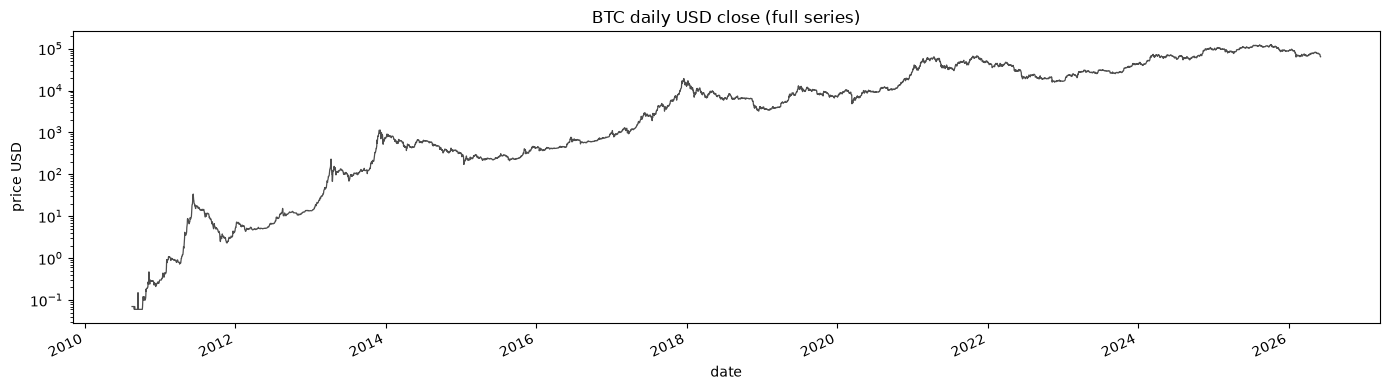

In [2]:
df = btc.fetch_bitcoin_daily()
dates = pd.DatetimeIndex(pd.to_datetime(df["date"]))
price = df["price_usd"].to_numpy(dtype=np.float64)
n = len(price)

print(f"Observations: {n}")
print(f"Date range: {dates[0].date()} → {dates[-1].date()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(dates, price, color="0.3", lw=0.9)
ax.set_title("BTC daily USD close (full series)")
ax.set_xlabel("date")
ax.set_ylabel("price USD")
btc.format_date_axis(ax, dates)
fig.tight_layout()
plt.show()

## Step 2: log transform (train + test)

$$y = \log(\text{price})$$

Natural log stabilises variance and puts multiplicative price moves on an additive scale. The warp model operates in **log space** throughout.

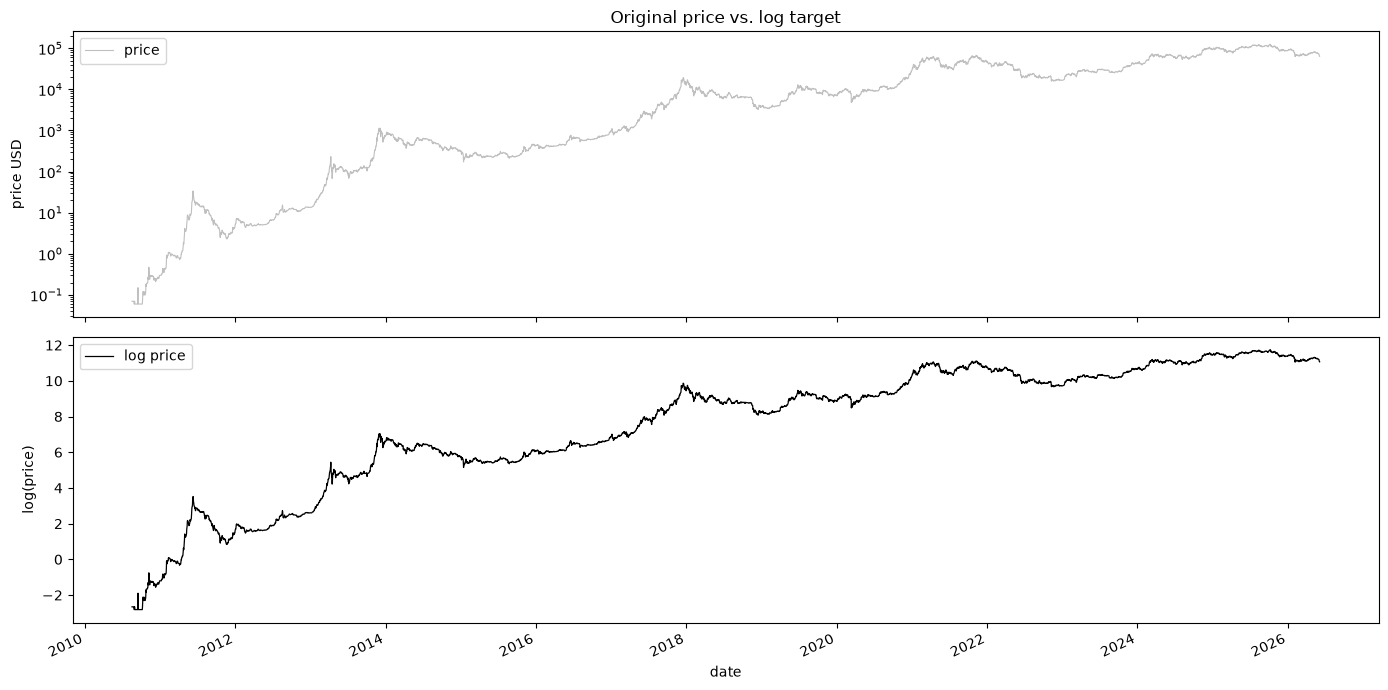

In [3]:
y = btc.log_price(price)
t = btc.normalized_time(n)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].semilogy(dates, price, color="0.75", lw=0.8, label="price")
axes[0].set_ylabel("price USD")
axes[0].legend()
axes[0].set_title("Original price vs. log target")

axes[1].plot(dates, y, "k", lw=0.9, label="log price")
axes[1].set_ylabel("log(price)")
axes[1].set_xlabel("date")
axes[1].legend()
btc.format_date_axis(axes[1], dates)
fig.tight_layout()
plt.show()

## Step 3: analyze log-trend, then prefit sine driver (train only)

First `analyze_log_trend()` detrends the log-price series. 
Then `prefit(..., n_sines=1)` fits a single macro sine on the **residual**, 
using macro peaks from the full train log series for phase alignment.


Train: 2010-08-18 → 2025-06-05 (n=5406)
Test:  2025-06-06 → 2026-06-05 (n=365)


ω=5.0  phase=0.103  time_scale=0.9061
trend pin endpoint_after=0.0011
last peak pin offset=0.00  endpoint residual=nan


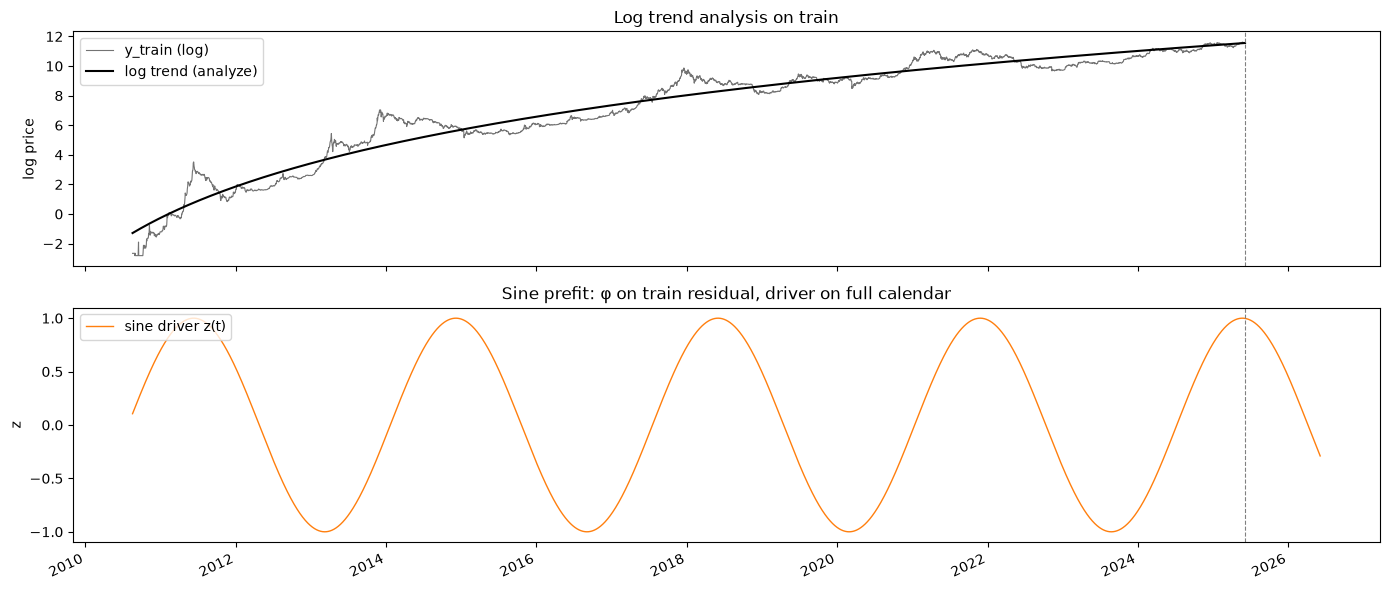

In [4]:
t_idx = btc.day_index(n)
split = btc.split_bitcoin_holdout(n, test_days=btc.TEST_DAYS, dates=dates)
train_idx, test_idx = split["train_idx"], split["test_idx"]
n_train = split["n_train"]
y_tr, y_te = y[train_idx], y[test_idx]
t_tr, t_te = t[train_idx], t[test_idx]
t_idx_tr = t_idx[train_idx]
dates_tr, dates_te = split["dates_train"], split["dates_test"]

print(f"Train: {dates_tr[0].date()} → {dates_tr[-1].date()} (n={n_train})")
print(f"Test:  {dates_te[0].date()} → {dates_te[-1].date()} (n={split['n_test']})")

prep = analyze_log_trend(y_tr, t_idx_tr)
peak_idx = btc.detect_btc_cycle_peaks(y_tr, dates_tr)
pf = prefit(
    prep.residual,
    t_tr,
    n_sines=1,
    peak_idx=peak_idx,
    omega=float(btc.N_CYCLE_PEAKS),
    envelope_init=True,
    t_full=t,
)
trend_pre = prep.trend
B_pre, C_pre, z_pre = prep.B, prep.C, prep.z
trend_pin = prep.pin
sine_fit = pf.sine_fit
z_pre = sine_fit["z"]
z_full = sine_fit["z_full"]
sine_fit_full = {**sine_fit, "z": z_full[:n_train]}

lp = sine_fit["last_peak_pin"]
ep = sine_fit["endpoint_pin"]
print(f"ω={sine_fit['omega']:.1f}  phase={sine_fit['phase']:.3f}  time_scale={sine_fit['time_scale']:.4f}")
print(f"trend pin endpoint_after={trend_pin['endpoint_after']:.4f}")
print(f"last peak pin offset={lp.get('last_peak_offset', 0):.2f}  endpoint residual={ep.get('endpoint_residual', float('nan')):.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax0, ax1 = axes
ax0.plot(dates_tr, y_tr, color="0.45", lw=0.8, label="y_train (log)")
ax0.plot(dates_tr, trend_pre, color="black", lw=1.5, label="log trend (analyze)")
ax0.axvline(dates_tr[-1], color="gray", ls="--", lw=0.8)
ax0.set_ylabel("log price")
ax0.set_title("Log trend analysis on train")
ax0.legend(loc="upper left")
ax1.plot(dates, z_full, color="C1", lw=1.0, label="sine driver z(t)")
ax1.axvline(dates_tr[-1], color="gray", ls="--", lw=0.8)
ax1.set_ylabel("z")
ax1.set_title("Sine prefit: φ on train residual, driver on full calendar")
ax1.legend(loc="upper left")
btc.format_date_axis(ax1, dates)
fig.tight_layout()
plt.show()


## Step 4: fit warp + MLP readout (train only)

Jointly learn B-spline knot parameters for `p(i)` and a small MLP readout on the **soft-warped** sine. `fit_lambda=0.9` weights error NLL heavily (daily data, long train window). Inspect the learned **offset** `p(i)−i` — end-anchored at zero at train end.

Training warp model on train slice


λ              = 0.9
epochs         = 24000
R² (train)     = 0.9871
RMSE (train)   = 0.3874
σ_y            = 0.4039
σ_t            = 0.2398
σ_index        = 6.6630
max offset     = 375.0 days
offset@end     = 0.0000 (anchor)


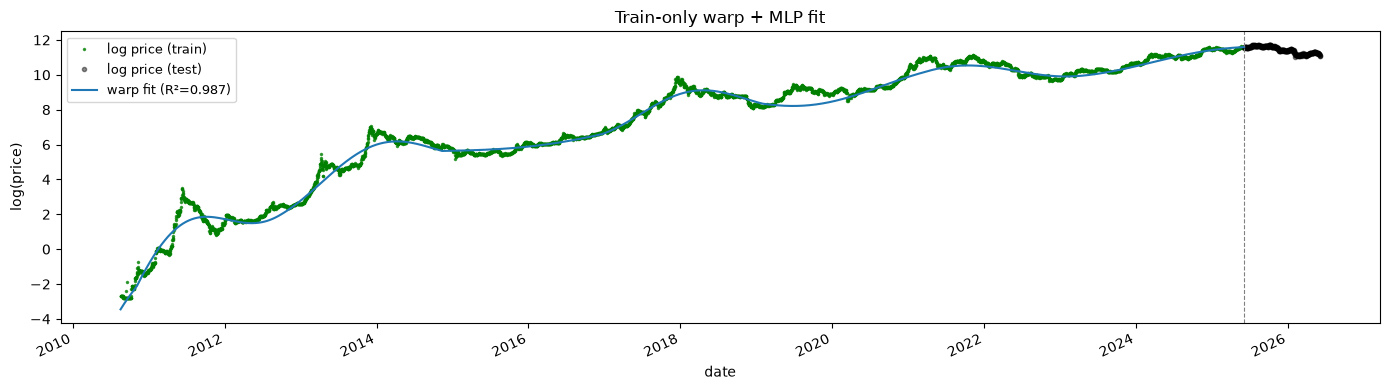

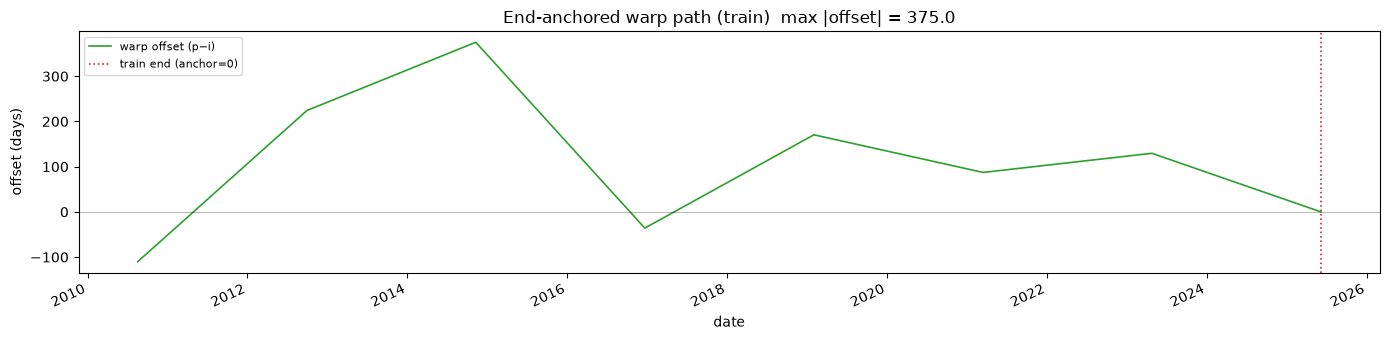

In [5]:
from warp_regression import per_index_rw_sigma

print("Training warp model on train slice")
fit = btc.fit_warp_model(
    y_tr, t_idx_tr, t_tr, sine_fit_full,
    fit_lambda=btc.FIT_LAMBDA,
    epochs=btc.EPOCHS,
    n_knots=btc.N_KNOTS,
)
fit["_y_test"] = y_te

y_hat = fit["y_hat"]
n_knots = fit["n_knots"]
print(f"λ              = {btc.FIT_LAMBDA}")
print(f"epochs         = {btc.EPOCHS}")
print(f"R² (train)     = {fit['r2']:.4f}")
print(f"RMSE (train)   = {fit['rmse']:.4f}")
print(f"σ_y            = {fit['warp']['sigma_y']:.4f}")
print(f"σ_t            = {fit['warp']['sigma_t']:.4f}")
print(f"σ_index        = {per_index_rw_sigma(fit['warp']['sigma_t'], n_train, n_knots):.4f}")
print(f"max offset     = {fit['warp']['max_abs_offset']:.1f} days")
print(f"offset@end     = {stored_path_offset_numpy(fit['warp']['p'])[-1]:.4f} (anchor)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_tr, y_tr, "g.", ms=3, alpha=0.7, label="log price (train)")
ax.plot(dates_te, y_te, "ko", ms=3, alpha=0.45, label="log price (test)")
ax.plot(dates_tr, y_hat, color="C0", lw=1.5, label=f"warp fit (R²={fit['r2']:.3f})")
ax.axvline(split["train_end_date"], color="gray", ls="--", lw=0.8)
ax.set_title("Train-only warp + MLP fit")
ax.set_xlabel("date")
ax.set_ylabel("log(price)")
ax.legend(loc="upper left", fontsize=9)
btc.format_date_axis(ax, dates)
fig.tight_layout()
plt.show()

p_tr = fit["warp"]["p"]
off = stored_path_offset_numpy(p_tr)
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(dates_tr, off, "C2", lw=1.2, label="warp offset (p−i)")
ax.axhline(0, color="k", lw=0.5, alpha=0.4)
ax.axvline(split["train_end_date"], color="C3", ls=":", lw=1.2, label="train end (anchor=0)")
ax.set_ylabel("offset (days)")
ax.set_xlabel("date")
ax.set_title(f"End-anchored warp path (train)  max |offset| = {fit['warp']['max_abs_offset']:.1f}")
ax.legend(loc="upper left", fontsize=8)
btc.format_date_axis(ax, dates)
fig.tight_layout()
plt.show()


## Step 5: holdout forecast — terror + error + combined 95% bands

Using fitted `σ_t` and `σ_y`, sample warp paths forward from the train-end anchor. Each path yields a forecast curve; percentiles form the **terror** band. **Combined** bands are percentiles of those paths plus independent `N(0, σ_y)` noise; **error** bands show observation noise alone around the point forecast.

Point forecast train/test corr = 1.000 / 0.888
Test RMSE (log) = 0.1693
Combined 95% coverage on test = 100.0%


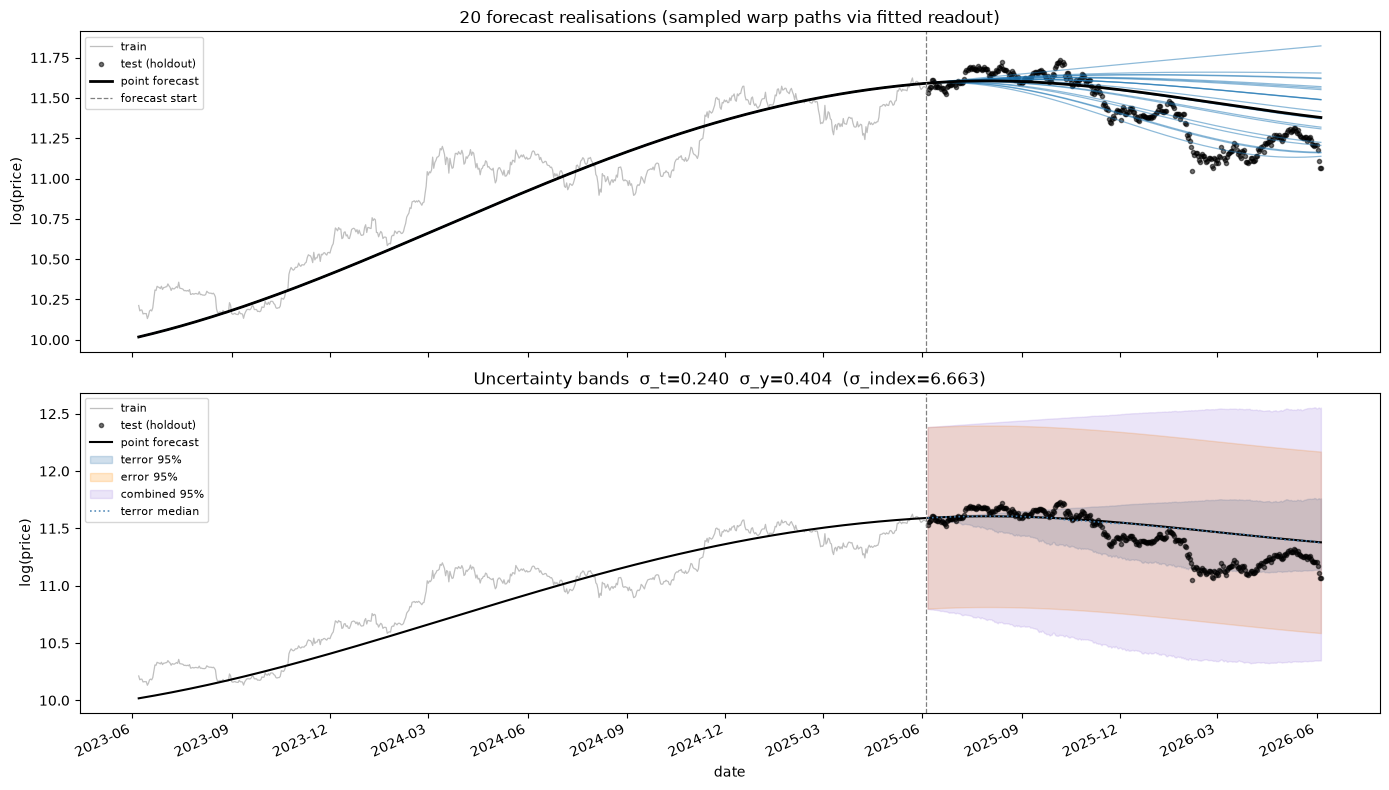

In [6]:
from warp_regression import predict_forecast_realisations_torch

n_show = btc.N_SINGLE_PATHS
hist_start = max(0, n_train - int(2 * 365.25))
dates_hist = dates[hist_start:]

fc = predict_forecast_realisations_torch(
    fit=fit,
    t_idx=t_idx,
    t_norm=t,
    z_full=z_full,
    n_obs=n_train,
    n_future=split["n_test"],
    n_draws=n_show,
    seed=43,
    noise_seed=44,
)
bands = fc["bands"]
y_point = fc["y_point"]
preds = fc["preds"][:n_show]

print(f"Point forecast train/test corr = {np.corrcoef(y_point[:n_train], fit['y_hat'])[0, 1]:.3f} / {np.corrcoef(y_point[test_idx], y_te)[0, 1]:.3f}")
print(f"Test RMSE (log) = {np.sqrt(np.mean((y_point[test_idx] - y_te) ** 2)):.4f}")
in_combined = (y_te >= bands["c_q_lo"][test_idx]) & (y_te <= bands["c_q_hi"][test_idx])
print(f"Combined 95% coverage on test = {in_combined.mean():.1%}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(dates[hist_start:n_train], y[hist_start:n_train], color="0.75", lw=0.9, label="train")
ax.plot(dates_te, y_te, "ko", ms=3, alpha=0.55, label="test (holdout)")
for k in range(preds.shape[0]):
    ax.plot(dates_hist, preds[k, hist_start:], alpha=0.5, lw=0.9, color="C0")
ax.plot(dates_hist, y_point[hist_start:], "k", lw=2, label="point forecast")
ax.axvline(split["train_end_date"], color="gray", ls="--", lw=0.9, label="forecast start")
ax.set_ylabel("log(price)")
ax.set_title(f"{preds.shape[0]} forecast realisations (sampled warp paths via fitted readout)")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
ax.plot(dates[hist_start:n_train], y[hist_start:n_train], color="0.75", lw=0.9, label="train")
ax.plot(dates_te, y_te, "ko", ms=3, alpha=0.55, label="test (holdout)")
ax.plot(dates_hist, y_point[hist_start:], "k", lw=1.5, label="point forecast")
ax.fill_between(dates_te, bands["t_q_lo"][test_idx], bands["t_q_hi"][test_idx], color="steelblue", alpha=0.25, label="terror 95%")
ax.fill_between(dates_te, bands["err_lo"][test_idx], bands["err_hi"][test_idx], color="darkorange", alpha=0.2, label="error 95%")
ax.fill_between(dates_te, bands["c_q_lo"][test_idx], bands["c_q_hi"][test_idx], color="mediumpurple", alpha=0.18, label="combined 95%")
ax.plot(dates_te, bands["t_q50"][test_idx], color="steelblue", ls=":", lw=1.2, alpha=0.9, label="terror median")
ax.axvline(split["train_end_date"], color="gray", ls="--", lw=0.9)
ax.set_ylabel("log(price)")
ax.set_xlabel("date")
ax.set_title(
    f"Uncertainty bands  σ_t={fc['sigma_t']:.3f}  σ_y={fc['sigma_y']:.3f}  "
    f"(σ_index={per_index_rw_sigma(fc['sigma_t'], n_train, n_knots):.3f})"
)
ax.legend(fontsize=8, loc="upper left")
btc.format_date_axis(ax, dates_hist)
fig.tight_layout()
plt.show()


## Step 6: 5-year forward forecast (full-series fit)

Retrain presize + warp + readout on **all** observations, then project 5 years beyond the last price. Same sampling as step 5: knot-smooth path **realisations** (thin lines) plus standard terror / error / combined bands.

Full-series presize + warp fit for 5-year forecast


Full-series R² = 0.9832  σ_y = 0.3686  σ_t = 0.2356


Forecast horizon: 2026-06-05 → 2031-06-05  (1826 days)
Point forecast at +5yr (log) = 12.320  price ≈ $224,157


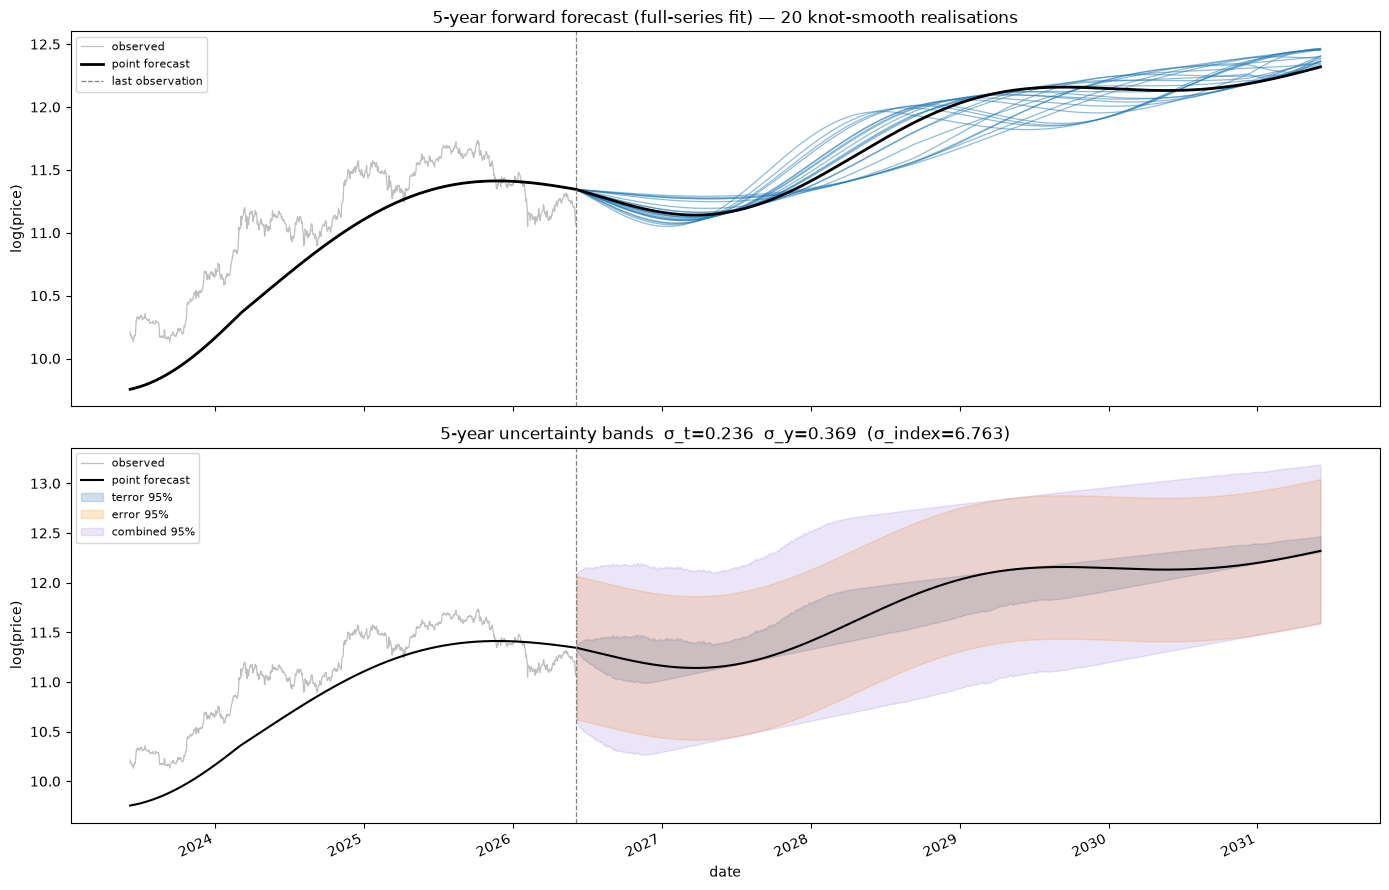

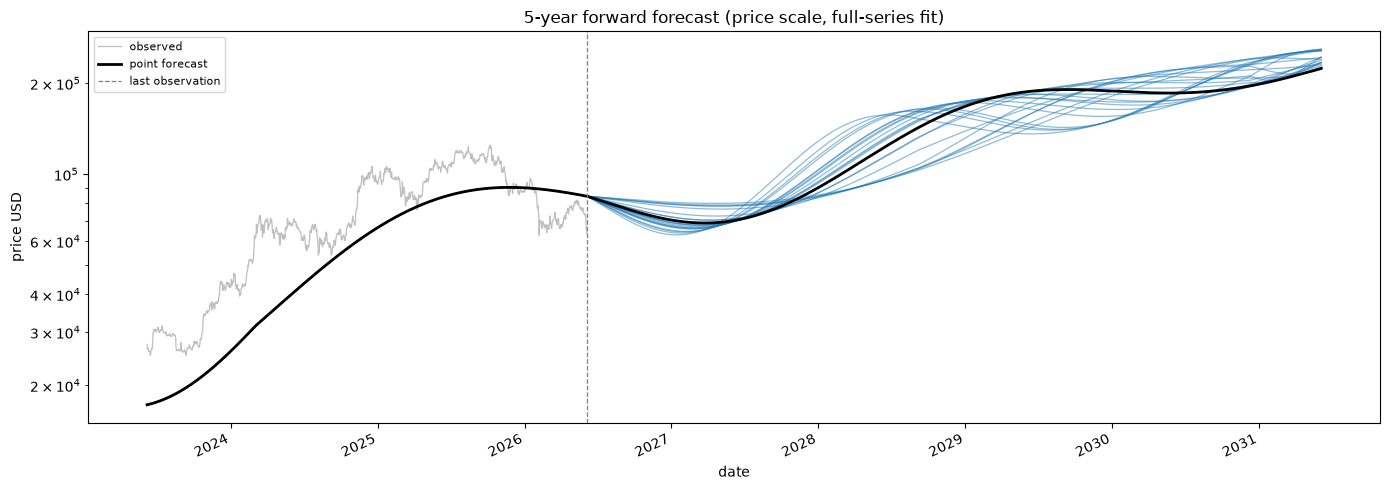

In [7]:
print("Full-series presize + warp fit for 5-year forecast")
prep_all = analyze_log_trend(y, t_idx)
peak_all = btc.detect_btc_cycle_peaks(y, dates)
pf_all = prefit(
    prep_all.residual, t, n_sines=1, peak_idx=peak_all,
    omega=float(btc.N_CYCLE_PEAKS), envelope_init=True, t_full=t,
)
trend_full_pre = prep_all.trend
sine_fit_all = pf_all.sine_fit
z_all = sine_fit_all["z_full"]
sine_fit_all_obs = {**sine_fit_all, "z": z_all}

fit_full = btc.fit_warp_model(
    y, t_idx, t, sine_fit_all_obs,
    fit_lambda=btc.FIT_LAMBDA,
    epochs=btc.EPOCHS,
    n_knots=btc.N_KNOTS,
)
n_knots_full = fit_full["n_knots"]
print(f"Full-series R² = {fit_full['r2']:.4f}  σ_y = {fit_full['warp']['sigma_y']:.4f}  σ_t = {fit_full['warp']['sigma_t']:.4f}")

n_future_5 = btc.FORECAST_5YR_DAYS
t_ext, t_idx_ext, z_ext, n_total_5 = btc.build_forecast_extension(n, n_future_5, sine_fit_all)
dates_ext = pd.date_range(dates[0], periods=n_total_5, freq="D")
dates_fut_5 = dates_ext[n:]

fc5 = predict_forecast_realisations_torch(
    fit=fit_full,
    t_idx=t_idx_ext,
    t_norm=t_ext,
    z_full=z_ext,
    n_obs=n,
    n_future=n_future_5,
    n_draws=n_show,
    seed=101,
    noise_seed=102,
)
bands5 = fc5["bands"]
y_point5 = fc5["y_point"]
preds5 = fc5["preds"][:n_show]

hist_start_5 = max(0, n - int(3 * 365.25))
fut_sl = np.arange(n, n_total_5)
print(f"Forecast horizon: {dates[-1].date()} → {dates_fut_5[-1].date()}  ({n_future_5} days)")
print(f"Point forecast at +5yr (log) = {y_point5[-1]:.3f}  price ≈ ${np.exp(y_point5[-1]):,.0f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(dates[hist_start_5:n], y[hist_start_5:n], color="0.75", lw=0.9, label="observed")
for k in range(preds5.shape[0]):
    ax.plot(dates_ext[hist_start_5:], preds5[k, hist_start_5:], alpha=0.5, lw=0.9, color="C0")
ax.plot(dates_ext[hist_start_5:], y_point5[hist_start_5:], "k", lw=2, label="point forecast")
ax.axvline(dates[-1], color="gray", ls="--", lw=0.9, label="last observation")
ax.set_ylabel("log(price)")
ax.set_title(f"5-year forward forecast (full-series fit) — {preds5.shape[0]} knot-smooth realisations")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
ax.plot(dates[hist_start_5:n], y[hist_start_5:n], color="0.75", lw=0.9, label="observed")
ax.plot(dates_ext[hist_start_5:], y_point5[hist_start_5:], "k", lw=1.5, label="point forecast")
ax.fill_between(dates_fut_5, bands5["t_q_lo"][fut_sl], bands5["t_q_hi"][fut_sl], color="steelblue", alpha=0.25, label="terror 95%")
ax.fill_between(dates_fut_5, bands5["err_lo"][fut_sl], bands5["err_hi"][fut_sl], color="darkorange", alpha=0.2, label="error 95%")
ax.fill_between(dates_fut_5, bands5["c_q_lo"][fut_sl], bands5["c_q_hi"][fut_sl], color="mediumpurple", alpha=0.18, label="combined 95%")
ax.axvline(dates[-1], color="gray", ls="--", lw=0.9)
ax.set_ylabel("log(price)")
ax.set_xlabel("date")
ax.set_title(
    f"5-year uncertainty bands  σ_t={fc5['sigma_t']:.3f}  σ_y={fc5['sigma_y']:.3f}  "
    f"(σ_index={per_index_rw_sigma(fc5['sigma_t'], n, n_knots_full):.3f})"
)
ax.legend(fontsize=8, loc="upper left")
btc.format_date_axis(ax, dates_ext[hist_start_5:])
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(dates[hist_start_5:n], price[hist_start_5:n], color="0.75", lw=0.9, label="observed")
for k in range(preds5.shape[0]):
    ax.semilogy(dates_ext[hist_start_5:], np.exp(preds5[k, hist_start_5:]), alpha=0.5, lw=0.9, color="C0")
ax.semilogy(dates_ext[hist_start_5:], np.exp(y_point5[hist_start_5:]), "k", lw=2, label="point forecast")
ax.axvline(dates[-1], color="gray", ls="--", lw=0.9, label="last observation")
ax.set_ylabel("price USD")
ax.set_xlabel("date")
ax.set_title("5-year forward forecast (price scale, full-series fit)")
ax.legend(fontsize=8, loc="upper left")
btc.format_date_axis(ax, dates_ext[hist_start_5:])
fig.tight_layout()
plt.show()

## Step 7: next-cycle length distribution (warp terror)

Using fitted **σ_t**, continue warp paths forward and measure the spacing to the **next peak** of the warped macro sine. The histogram shows how long the upcoming cycle is under timing uncertainty; the dashed line is the **nominal** mean cycle length \(n/\omega\) on the train calendar.

Nominal cycle ≈ 1308 days  |  sample median = 988 days  |  σ_t = 0.236


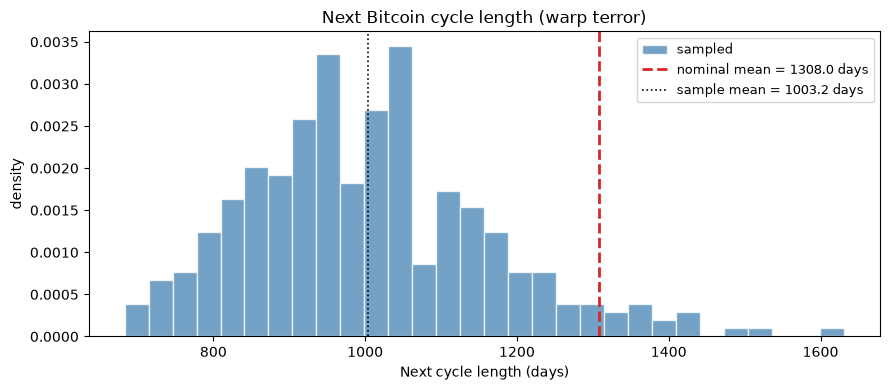

In [8]:
from warp_regression import analyze_cycle_lengths, plot_cycle_length_distribution

cyc = analyze_cycle_lengths(
    fit=fit_full,
    sine_fit=sine_fit_all,
    n_calendar=n,
    unit="days",
    n_paths=500,
    seed=7,
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc, ax=ax, title="Next Bitcoin cycle length (warp terror)")
print(
    f"Nominal cycle ≈ {cyc.mean_cycle_length:.0f} days  |  "
    f"sample median = {np.median(cyc.lengths):.0f} days  |  "
    f"σ_t = {cyc.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()

| 3 | Train/test split; analyze_log_trend + prefit(n_sines=1) on train |
